#**ANALISIS DATASET BIKE BUYERS**

#**Import Library**

In [132]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

#**Bussiness Understanding**

##**Bussiness Objective**

Dataset Bike Buyers

Dataset ini berisi data dari 1000 pelanggan/responden yang berkaitan dengan keputusan pembelian sepeda. Tujuan utama dari analisis ini adalah untuk memahami karakteristik pelanggan, mengidentifikasi faktor yang mempengaruhi keputusan pembelian sepeda, serta membantu perusahaan dalam meningkatkan strategi pemasaran agar penjualan sepeda dapat lebih optimal.

Dataset ini terdiri dari 1000 baris dan 13 kolom yang mencakup informasi demografi pelanggan, kondisi ekonomi, status pembelian sepeda serta informasi lainnya yang berkaitan dengan pelanggan.

##**Assess Situation**

Situasi dalam dataset ini berfokus pada data pelanggan yang berkaitan dengan keputusan pembelian sepeda. Dataset ini mencakup berbagai karakteristik pelanggan seperti usia, pendapatan, pendidikan, status pernikahan, jumlah anak, serta jarak tempat tinggal ke tempat kerja.

Berdasarkan data tersebut, diperlukan pemahaman yang mendalam untuk melihat pola hubungan antara karakteristik pelanggan dengan keputusan pembelian sepeda, agar analisis yang dilakukan nantinya dapat memberikan insight/informasi yang jelas dan relevan.

##**Analytic Goals & Project Plan**


*   Mengidentifikasi Karakteristik Pembeli Sepeda
*   Menghasilkan Visualisasi Data
*   Menyediakan Dasar Pengambilan Keputusan
*   Menganalisis Faktor yang Mempengaruhi Keputusan Pembelian Sepeda

#**Data Understanding**

##**Memuat Dataset**

In [133]:
file = "/content/drive/MyDrive/Praktikum/bike_buyers.csv"
df = pd.read_csv(file)

df


,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes
997,11809,Married,NaN,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No


##**Deskripsi Data**

###**Informasi Dasar**

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    993 non-null    object 
 2   Gender            989 non-null    object 
 3   Income            994 non-null    float64
 4   Children          992 non-null    float64
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home Owner        996 non-null    object 
 8   Cars              991 non-null    float64
 9   Commute Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               992 non-null    float64
 12  Purchased Bike    1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 101.7+ KB


Berdasarkan data di atas, diketahui bahwa dataset ini memiliki 1000 baris  dan 13 kolom data.

###**Informasi lanjutan**

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    993 non-null    object 
 2   Gender            989 non-null    object 
 3   Income            994 non-null    float64
 4   Children          992 non-null    float64
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home Owner        996 non-null    object 
 8   Cars              991 non-null    float64
 9   Commute Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               992 non-null    float64
 12  Purchased Bike    1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 101.7+ KB


1. ID: Jumlah baris: 1000 Tipe data: int64 Deskripsi: ID responden
2. Marital Status: 993 Tipe data: object Deskripsi: status pernikahan
3. Gender: 989 Tipe data : object Deskripsi: Jenis Kelamin
4. Income: 994 Tipe data: float64 Deskripsi: Pendapatan
5. Children: 992 Tipe data: float64 Deskripsi: Jumlah Anak
6. Education: 1000 Tipe data: object Deskripsi: tingkat pendidikan
7. Occupation: 1000 Tipe data: object Deskripsi: kemampuan pekerjaan
8. Home Owner: 996 Tipe data: object Deskripsi: status kepemilikan rumah
9. Cars: 991 Tipe data: float64 Deskripsi: jumlah kepemilikan mobil
10. Commute Distance: 1000 Tipe data: object Deskripsi: jarak tempat kerja
11. Region: 1000 Tipe data: object Deskripsi: benua
12. Age: 992 Tipe data: float64 Deskripsi: umur
13. Purchased Bike: 1000 Tipe data: object Deskripsi: status kepemilikan sepeda

###**Informasi Statistik Deskriptif**

In [136]:
df.describe(include='all')

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
count,1000.000000,993,989,994.000000,992.000000,1000,1000,996,991.000000,1000,1000,992.000000,1000
unique,NaN,2,2,NaN,NaN,5,5,2,NaN,5,3,NaN,2
top,NaN,Married,Male,NaN,NaN,Bachelors,Professional,Yes,NaN,0-1 Miles,North America,NaN,No
freq,NaN,535,500,NaN,NaN,306,276,682,NaN,366,508,NaN,519
mean,19965.992000,NaN,NaN,56267.605634,1.910282,NaN,NaN,NaN,1.455096,NaN,NaN,44.181452,NaN
std,5347.333948,NaN,NaN,31067.817462,1.626910,NaN,NaN,NaN,1.121755,NaN,NaN,11.362007,NaN
min,11000.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,25.000000,NaN
25%,15290.750000,NaN,NaN,30000.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,35.000000,NaN
50%,19744.000000,NaN,NaN,60000.000000,2.000000,NaN,NaN,NaN,1.000000,NaN,NaN,43.000000,NaN
75%,24470.750000,NaN,NaN,70000.000000,3.000000,NaN,NaN,NaN,2.000000,NaN,NaN,52.000000,NaN


1. Count (Kelengkapan Data) Berdasarkan data, total baris data adalah 1000. Maka dapat disimpulkan:



*   Martial status hilang 7 data (1000-993)
*   Gender hilang 11 data (1000-989)
*   Income hilang 6 data (1000-994)
*   Children hilang 8 data (1000-992)
*   Home owner hilang 4 data (1000-996)
*   Cars hilang 9 data (1000-991)
*   Age hilang 8 data (1000-992)

Kesimpulan: Martial status, Gender, Income, Children, Home owner, Cars, dan Age mengandung missing values, sementara kolom lainnya udah lengkap (1000 data)

---
2. Mean Vs Median (Distribusi Data)

Kolom Income
Mean = 56.267,61
Median = 60.000,00 - Nilai rata-rata sedikit lebih kecil dari median.
Hal ini menunjukkan sebagian data memiliki income yang lebih rendah sehingga menarik mean ke bawah, namun secara umum distribusi masih relatif mendekati simetris dengan sedikit kecenderungan left-skewed.

Kolom Children
Mean = 1,91
Median = 2,00 - Nilai rata-rata hampir sama dengan median.
Ini menunjukkan distribusi jumlah anak cukup seimbang tanpa pengaruh outlier yang signifikan, mayoritas responden memiliki sekitar 2 anak.

Kolom Cars
Mean = 1,46
Median = 1,00 - Nilai rata-rata lebih besar dari median.
Hal ini menandakan terdapat sebagian kecil responden yang memiliki jumlah mobil lebih banyak (3–4 mobil) sehingga menarik rata-rata ke atas, menunjukkan distribusi sedikit right-skewed.

Kolom Age
Mean = 44,18
Median = 43,00 - Nilai rata-rata sedikit lebih besar dari median.
Ini menunjukkan adanya beberapa responden dengan usia cukup tinggi yang membuat mean naik, namun distribusi usia masih relatif mendekati simetris.

Kesimpulan

Secara keseluruhan, distribusi data numerik cenderung mendekati simetris dengan sedikit right-skewed, terutama pada variabel Cars dan Age, di mana terdapat beberapa nilai tinggi yang memengaruhi rata-rata, namun tidak terlalu ekstrem.


---

3. Min dan Max (Validasi Logika)

Income
Min = 10.000,00
Max = 170.000,00

Children
Min = 0
Max = 5

Cars
Min = 0
Max = 4

Age
Min = 25
Max = 89

Kesimpulan:

Nilai Income maksimum sebesar 170.000 menunjukkan adanya responden dengan pendapatan sangat tinggi, kemungkinan termasuk kelompok ekonomi atas.

Nilai Children maksimum sebesar 5 masih wajar secara demografis dan tidak menunjukkan indikasi kesalahan input.

Nilai Cars maksimum sebesar 4 menunjukkan sebagian kecil responden memiliki banyak kendaraan, kemungkinan berasal dari kelompok berpendapatan tinggi.

Rentang Age dari 25 hingga 89 tahun adalah logis untuk dataset konsumen, meskipun usia mendekati 90.


##**Verifikasi Kualitas Data**

###**Data Type Check**

Dari data di bawah ini, semua kolom sudah memiliki tipe data yang sesuai.

In [137]:
df.dtypes

,0
ID,int64
Marital Status,object
Gender,object
Income,float64
Children,float64
Education,object
Occupation,object
Home Owner,object
Cars,float64
Commute Distance,object


###**Incosistent Values**

Pada tahap ini, akan dilakukan pengecekan kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

Namun dari hasil pengecekkan data pada setiap kolom di bawah ini, tidak terdapat data yang inkonsisten.

In [138]:
print(df['ID'].unique())

[12496 24107 14177 24381 25597 13507 27974 19364 22155 19280 22173 12697
 11434 25323 23542 20870 23316 12610 27183 25940 25598 21564 19193 26412
 27184 12590 17841 18283 18299 16466 19273 22400 20942 18484 12291 28380
 17891 27832 26863 16259 27803 14347 17703 17185 29380 23986 24466 29097
 19487 14939 13826 20619 12558 24871 17319 28906 12808 20567 25502 15580
 24185 19291 16713 16185 14927 29337 29355 25303 14813 16438 14238 16200
 24857 26956 14517 12678 16188 27969 15752 27745 20828 19461 26941 28412
 24485 16514 17191 19608 24119 25458 26886 28436 19562 15608 16487 17197
 12507 23940 19441 26852 12274 20236 24149 26139 18491 22707 20430 27494
 26829 28395 21006 14682 17650 29191 15030 24140 22496 24065 19914 12871
 22988 15922 12344 23627 27775 29301 12716 12472 20970 26818 12993 14192
 19477 26796 21094 12234 28683 17994 24273 26547 22500 23993 14832 16614
 20877 20729 22464 19475 19675 12728 26154 29117 17845 25058 23426 14798
 12664 23979 25605 20797 21980 25460 29181 24279 22

In [139]:
print(df['Marital Status'].unique())

['Married' 'Single' nan]


In [140]:
print(df['Gender'].unique())

['Female' 'Male' nan]


In [141]:
print(df['Income'].unique())

[ 40000.  30000.  80000.  70000.  10000. 160000.  20000.     nan  90000.
 170000.  60000. 100000. 130000. 120000. 150000.  50000. 110000.]


In [142]:
print(df['Children'].unique())

[ 1.  3.  5.  0.  2.  4. nan]


In [143]:
print(df['Education'].unique())

['Bachelors' 'Partial College' 'High School' 'Partial High School'
 'Graduate Degree']


In [144]:
print(df['Occupation'].unique())

['Skilled Manual' 'Clerical' 'Professional' 'Manual' 'Management']


In [145]:
print(df['Home Owner'].unique())

['Yes' 'No' nan]


In [146]:
print(df['Cars'].unique())

[ 0.  1.  2.  4. nan  3.]


In [147]:
print(df['Commute Distance'].unique())

['0-1 Miles' '2-5 Miles' '5-10 Miles' '1-2 Miles' '10+ Miles']


In [148]:
print(df['Region'].unique())

['Europe' 'Pacific' 'North America']


In [149]:
print(df['Age'].unique())

[42. 43. 60. 41. 36. 50. 33. 58. nan 54. 55. 35. 45. 38. 59. 47. 56. 34.
 63. 29. 40. 44. 32. 26. 31. 62. 30. 28. 65. 48. 66. 46. 52. 39. 61. 37.
 68. 51. 49. 53. 27. 25. 67. 57. 70. 78. 69. 64. 89. 80. 73. 74. 71. 72.]


In [150]:
print(df['Purchased Bike'].unique())

['No' 'Yes']


###**Missing Values**

Pada tahap ini, akan dilihat seberapa banyak data yang hilang pada seluruh kolom. Dan terlihat bahwa kolom:

* Marital Status

Memiliki missing values sekitar 0.7%, ini memang terlihat kecil dan mungkin tidak berpengaruh namun tetap perlu ditangani.

* Gender

Memiliki missing values sekitar 1,1%, yang dimana persentase ini juga rendah sehingga tidak terlalu memengaruhi analisis, namun tetap perlu ditangani.

* Income

Memiliki missing values sekitar 0,6%, yang dimana nilai yang hilang cukup kecil dan dapat diatasi.

* Children

Memiliki missing values sekitar 0,8%, yang dimana masih tergolong rendah.

* Home owner

Memiliki missing values sekitar 0,4%, yang dimana persentase ini sangat kecil sehingga tidak menjadi masalah besar pada dataset.

* Cars

Memiliki missing values sekitar 0,9%, yang dimana masih dalam batas wajar.

* Age
Memiliki missing values sekitar 0,8%, yang dimana jumlahnya kecil dan tidak terlalu berdampak signifikan terhadap distribusi data.

In [151]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
ID,0.0
Marital Status,0.7
Gender,1.1
Income,0.6
Children,0.8
Education,0.0
Occupation,0.0
Home Owner,0.4
Cars,0.9
Commute Distance,0.0


###**Duplicated Values**

Pada tahap ini, akan dilakukan pengecekan terhadap data duplikat pada dataset. Proses ini penting dilakukan agar kualitas data tetap terjaga, sehingga analisis yang dihasilkan lebih akurat, konsisten, dan dapat memberikan insight yang lebih valid.

Namun, dari hasil pengecekan tidak terdapat satupun data yang terduplikat dalam dataset ini. Sehingga tidak ada yang perlu ditangani.

In [152]:
df[df.duplicated()]

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike


###**Outliers Values**

Pada tahap ini, akan mengecek nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan dibangun nantinya.

Dari data dibawah ini terlihat yaitu outliers dari kolom:

Income sebesar 1%

Cars sebesar 5,9%

Age sebesar 0,4%

In [153]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
ID,0.0
Income,1.0
Children,0.0
Cars,5.9
Age,0.4


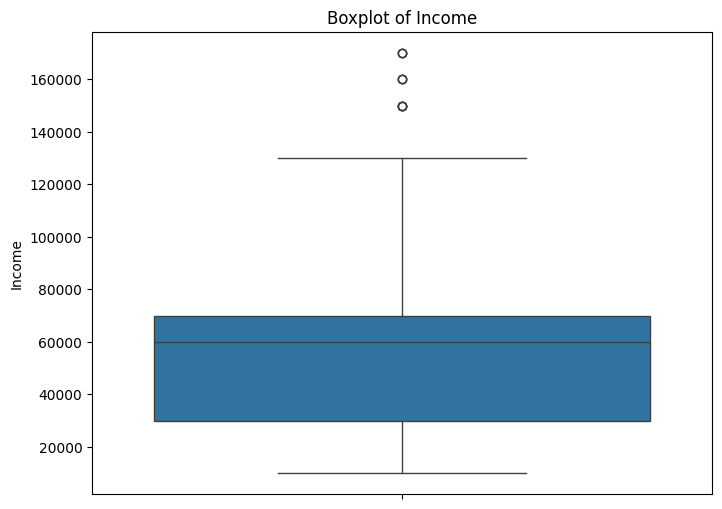

In [154]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Income'])
plt.title('Boxplot of Income')
plt.ylabel('Income')
plt.show()

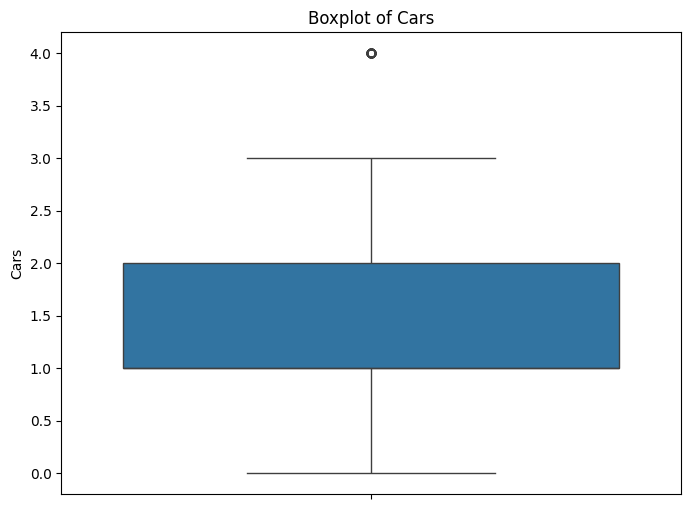

In [155]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Cars'])
plt.title('Boxplot of Cars')
plt.ylabel('Cars')
plt.show()

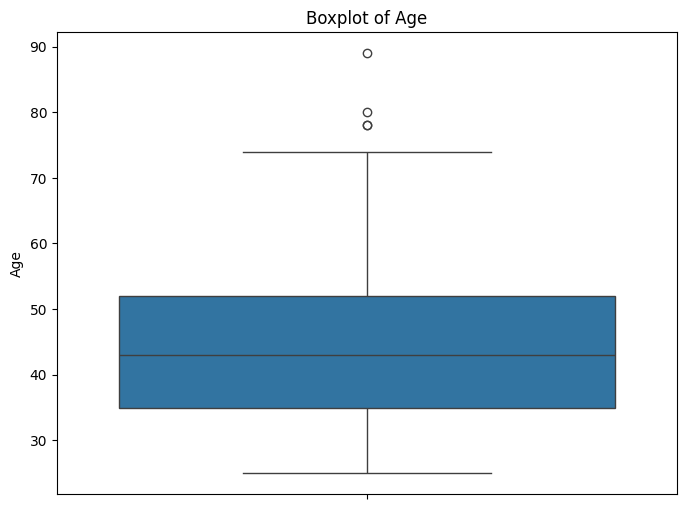

In [156]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.show()

##**Eksplorasi Data (EDA)**

###**Comparison/Perbandingan**

Aktivitas: Membandingkan jarak ke kantor dengan keputusan pembelian sepeda.

Tujuan: Mengidentifikasi pengaruh keputusan pembelian berdasarkan jarak rumah ke tempat kerja.

Visualisasi: Bar Chart (Grafik Batang).

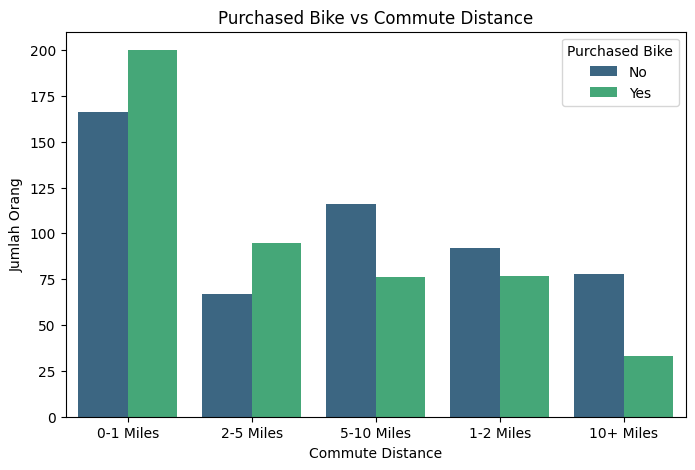

In [157]:
plt.figure(figsize=(8,5))
sns.countplot(x='Commute Distance', hue='Purchased Bike', data=df, palette='viridis')
plt.title('Purchased Bike vs Commute Distance')
plt.xlabel('Commute Distance')
plt.ylabel('Jumlah Orang')
plt.show()

Berdasarkan diagram batang tersebut, dapat dapat dilihat bahwa semakin jauh jarak rumah seseorang dari tempat kerjanya, maka minat membeli sepeda cenderung menurun.

Dari hal ini dapat disimpulkan bahwasanya sepeda lebih memungkinkan untuk menjadi alternatif transportasi yang digunakan dalam jarak dekat(0-1 miles).

###**Composition/Komposisi**

Aktivitas: Melihat proporsi atau persentase pembelian sepeda terhadap region.

Tujuan: Mengetahui region mana yang mendominasi penjualan sepeda secara keseluruhan.

Visualisasi: Pie Chart (Grafik Lingkaran).

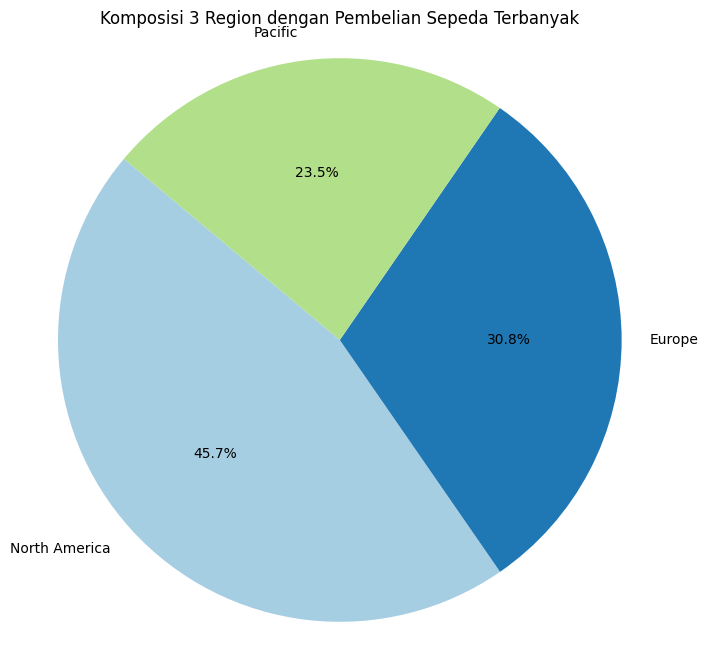

In [158]:

top3_region = (
    df[df['Purchased Bike'] == 'Yes']
    .groupby('Region')
    .size()
    .sort_values(ascending=False)
    .head(3)
)

plt.figure(figsize=(8,8))
top3_region.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)

plt.title('Komposisi 3 Region dengan Pembelian Sepeda Terbanyak')
plt.ylabel('')
plt.axis('equal')
plt.show()

Berdasarkan Pie Chart diatas, dapat diketahui bahwasanya pembelian sepeda terbanyak terjadi di region North America

Maka dari itu dapat ditarik kesimpulan bahwa region North America memiliki peminat/pasar yang lebih besar dalam pembelian sepeda ketimbang region lainnya.

###**Distribution/Distribusi**

Aktivitas: Menganalisis penyebaran dari beberapa kolom data.

Tujuan: Melihat apakah persebaran data normal, atau skewed. agar dapat memudahkan dalam proses data preparation nantinya.

Visualisasi: Histogram/Histoplot.

1. Melihat distribusi income terhadap pembeli sepeda

    Dari  histogram dibawah dapat terlihat bahwa distribusi Income cenderung menyebar dengan konsentrasi terbesar pada kelompok pendapatan rendah-menengah.

    Hal ini menandakan bahwa sepeda bukan produk yang pembeliannya didominasi oleh kelompok berpendapatan tinggi, melainkan lebih populer di kalangan konsumen dengan pendapatan stabil.

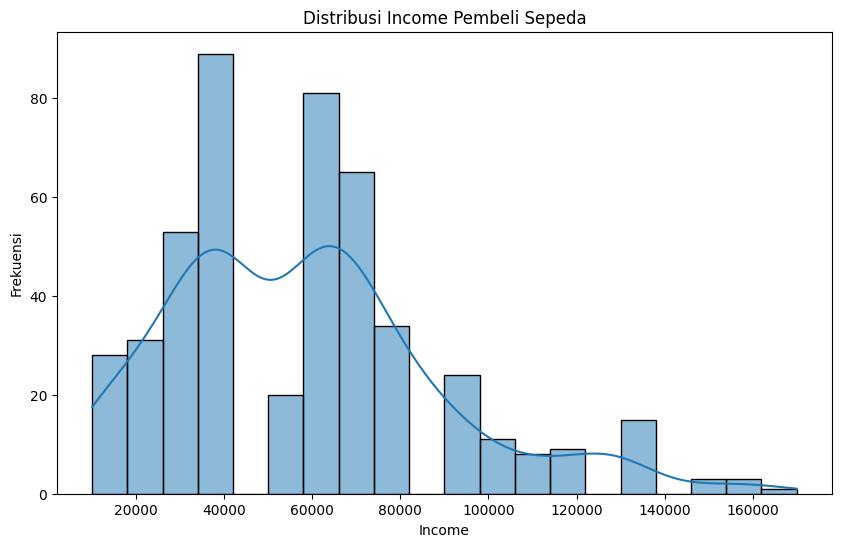

In [159]:
income_buyer = df[df['Purchased Bike'] == 'Yes']['Income']

plt.figure(figsize=(10, 6))
sns.histplot(income_buyer, bins=20, kde=True)
plt.title('Distribusi Income Pembeli Sepeda')
plt.xlabel('Income')
plt.ylabel('Frekuensi')
plt.show()

1. Melihat distribusi data Income (Pendapatan)

    Dari  histogram dibawah dapat terlihat bahwa distribusi Income cederung menumpuk di bagian kiri (skewed-left).

    Menandakan bahwa responden dalam dataset ini dominan memmiliki pendapatan yang bisa dibilang menengah ke bawah.

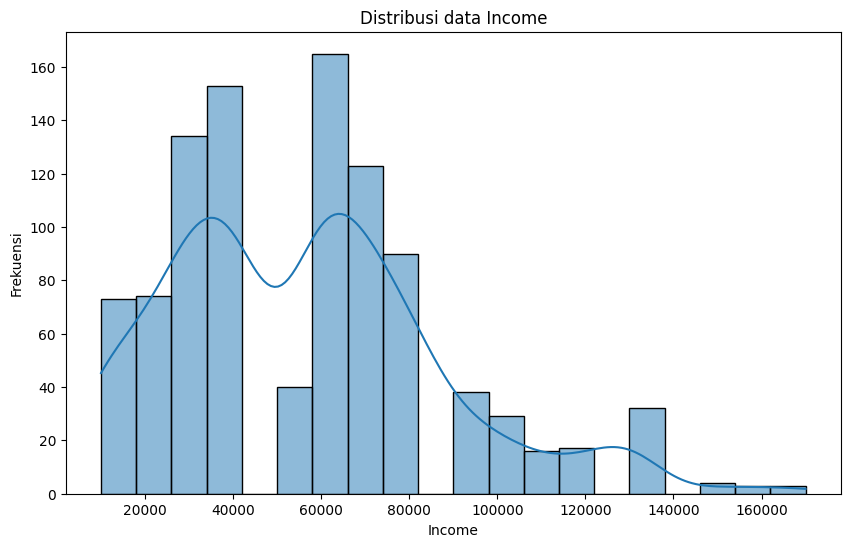

In [160]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], bins=20, kde=True)
plt.title('Distribusi data Income')
plt.xlabel('Income')
plt.ylabel('Frekuensi')
plt.show()

 1. Melihat distribusi data Age (Usia)   
    Dari  histogram dibawah dapat terlihat bahwa distribusi Usia cederung menumpuk di bagian kiri (skewed-left).

    Menandakan bahwa responden dalam dataset ini dominan berusia dibawah 60 tahun.

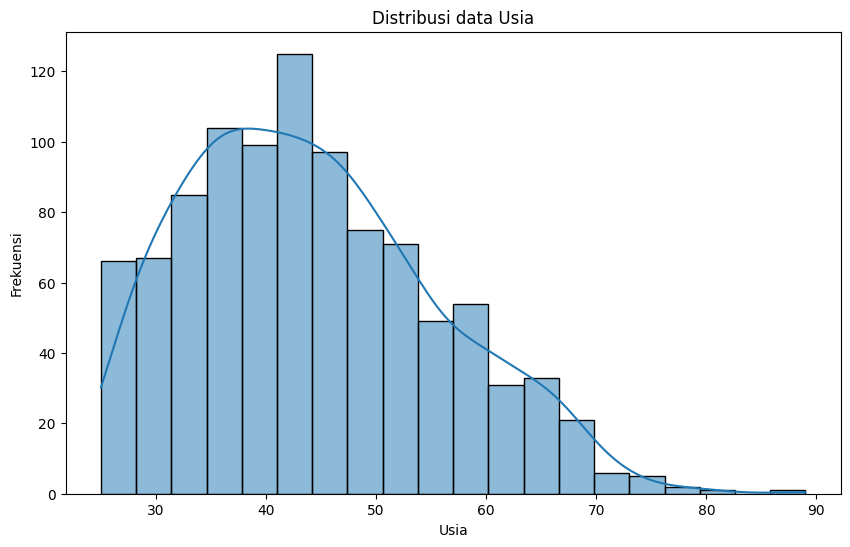

In [161]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribusi data Usia')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.show()

###**Relationship/Hubungan**

In [162]:
df.corr(numeric_only=True)

,ID,Income,Children,Cars,Age
ID,1.000000,-0.075081,-0.028747,0.022125,-0.054238
Income,-0.075081,1.000000,0.261053,0.439980,0.170845
Children,-0.028747,0.261053,1.000000,0.280243,0.531668
Cars,0.022125,0.439980,0.280243,1.000000,0.186398
Age,-0.054238,0.170845,0.531668,0.186398,1.000000


Aktivitas: Menganalisis korelasi antara nilai pendapatan (Income)  dengan jumlah kepemilikan mobil (Cars).

Tujuan: Mengetahui apakah semakin tinggi pendapatan akan memperbesar potensi memiliki mobil.

Visualisasi: Heatmap

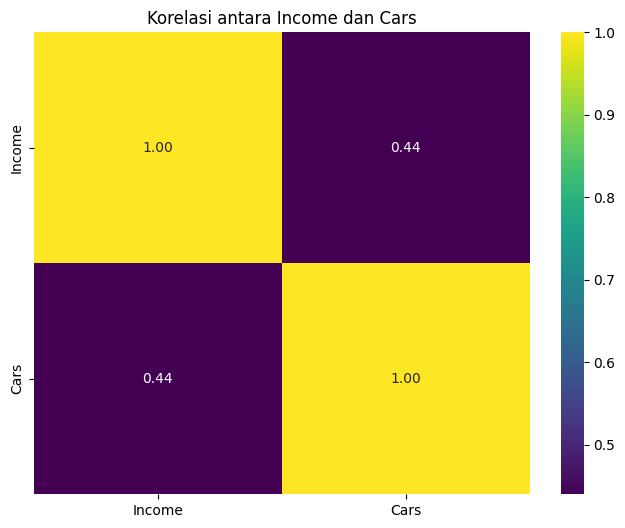

In [163]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Income', 'Cars']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Income dan Cars')
plt.show()

Dari hasil visualisasi diatas dapat terlihat bahwa ada hubungan positif meskipun hanya memiliki rasio 0.44.

Jadi dapat disimpulkan bahwa pendapatan seseorang  tidak berpengaruh signifikan pada keputusan membeli mobil, jadi masih ada kemungkinan responden tersebut membeli akan alat transportasi alternatif lain seperti sepeda.

#**Data Preparation**

Pada tahap ini, saya melakukan serangkaian proses untuk mempersiapkan data agar siap digunakan. Proses data preparation ini mencakup beberapa tahapan, yaitu pengecekan tipe data, penanganan nilai yang tidak konsisten, penanganan data yang hilang, penanganan data duplikat, penanganan outlier, konstruksi data, dan reduksi data. Penanganan dilakukan berdasarkan hasil identifikasi masalah pada tahapan sebelumnya di data understanding.

##**Data Type**

Pada tahap ini akan dilakukan penanganan terhadap tipe data yang tidak sesuai dengan konteks/kategori kolom.

Namun dikarenakan seluruh kolom sudah memiliki tipe data yang sesuai, jadi tidak diperlukan penanganan khusus.

##**Inconsistent Values**

Dikarenakan tidak terdapat data yang tidak konsisten, maka tidak perlu ditangani dan dapat diskip ke proses selanjutnya.

##**Missing Values**

Selanjutnya pada tahapan ini dilakukan penanganan terhadap data yang hilang atau tidak tersedia dalam dataset. Keberadaan missing values dapat memengaruhi insight nantinya jika tidak ditangani dengan baik walaupun rasio missing valuesnya kecil. Penanganan missing values dilakukan dengan beberapa pendekatan tergantung pada kondisi data, seperti mengisi nilai yang hilang dengan nilai rata-rata (mean), nilai tengah (median), atau nilai yang paling sering muncul (modus) untuk data numerik maupun kategorikal. Apabila jumlah missing values pada suatu atribut lebih dari 70%, maka atribut atau baris tersebut dapat dipertimbangkan untuk dihapus tetapi jika masih dibawah 70% maka dapat dilakuan imputasi.

Secara keseluruhan, seluruh missing values pada dataset ini masih berada dalam persentase yang bisa dibilang sangat rendah, yaitu rasionya di bawah 1,5%, sehingga proses imputasi yang dilakukan sebenarnya tidak akan memberikan dampak yang signifikan terhadap distribusi data maupun performa model. Pemilihan antara modus dan median didasarkan pada tipe data masing-masing kolom, di mana modus digunakan untuk data kategorikal dan median digunakan untuk data numerik guna memastikan hasil imputasi yang paling representatif dan akurat.

1. **Marital Status**

Memiliki missing values dengan rasio 0,7%. Kolom ini bersifat kategorikal, sehingga metode imputasi yang saya digunakan disini ialah Modus, yaitu mengisi nilai yang hilang dengan kategori yang paling sering muncul. Alasan pemilihan metode ini adalah dikarenakan data kategorikal tidak memiliki nilai rata-rata yang bermakna, sehingga modus menjadi pilihan yang paling tepat dan representatif untuk mempertahankan distribusi kategori yang sudah ada.

In [164]:
df['Marital Status'] = df['Marital Status'].fillna(df['Marital Status'].dropna().mode())

2. **Gender**

Memiliki missing values dengan rasio 1,1%. Sama seperti martial status sebelumnya, kolom ini juga bersifat kategorikal sehingga metode imputasi yang cocok digunakan adalah Modus . Nilai yang hilang akan diisi dengan kategori gender yang paling dominan dalam dataset. Dikarenakan peresentasenya yang kecil jadi tidak akan terlalu mempengaruhi distribusi datanya.

In [165]:
df['Gender'] = df['Gender'].fillna(df['Gender'].dropna().mode())

3. **Income**

    Memiliki missing values dengan rasio 0,6%. Kolom ini bersifat numerik dan cenderung memiliki distribusi yang tidak simetris atau condong ke kiri, sehingga metode imputasi yang akan saya gunakan adalah Median. Median lebih aman terhadap nilai ekstrem dibandingkan mean, sehingga nilai yang diimputasi lebih mencerminkan kondisi data secara keseluruhan tanpa terpengaruh oleh outlier yang ada pada kolom pendapatan. Walaupun memang rasio sangat kecil, dan dengan metode apapun tidak akan terlalu terpengaruh, namun saya disini tetap memakai metode median.

In [166]:
df['Income'] = df['Income'].fillna(df['Income'].dropna().median())

4. **Children**

    Memiliki missing values dengan rasio 0,8%. Kolom ini bersifat numerik yang merepresentasikan jumlah anak. Metode imputasi yang akan saya gunakan adalah Median, karena jumlah anak merupakan data yang cenderung memiliki distribusi tidak normal dan bernilai bulat, sehingga median sepertinya lebih cocok untuk digunakan ketimbang mean yang bisa menghasilkan nilai desimal yang tidak wajar untuk konteks jumlah anak.

In [167]:
df['Children'] = df['Children'].fillna(df['Children'].dropna().mode())

5. **Home Owner**

    Memiliki missing values dengan rasio 0,4%. Kolom ini bersifat kategorikal ( Ya/Tidak ), sehingga metode imputasi yang digunakan adalah Modus. Karena hanya ada dua kemungkinan nilai, dengan menggunakan modus secara langsung akan mencerminkan kondisi mayoritas dalam dataset dan pengisian dengan nilai yang paling dominan tidak akan mengubah keseimbangan distribusi secara signifikan mengingat rasionya yang sangat kecil.

In [168]:
df['Home Owner'] = df['Home Owner'].fillna(df['Home Owner'].dropna().mode())

6. **Cars**

    Memiliki missing values dengan rasio 0,9%. Kolom ini bersifat numerik yang merepresentasikan jumlah mobil dari responden. Metode imputasi yang digunakan adalah Median, dengan alasan yang sama seperti di kolom Children, yaitu karena jumlah kendaraan merupakan bilangan bulat dan distribusinya bisa condong ke salah satu sisi, sehingga median lebih representatif dibandingkan mean untuk menghindari hasil imputasi berupa nilai desimal yang tidak relevan secara konteks.

In [169]:
df['Cars'] = df['Cars'].fillna(df['Cars'].dropna().median())

7. **Age**

memiliki missing values dengan rasio 0,8%. Kolom ini bersifat numerik dan merepresentasikan usia. Metode imputasi yang digunakan adalah Median , dikarenakan distribusi usia dalam dataset ini tidak terlalu  simetris dan  dipengaruhi oleh nilai ekstrem pada usia tertentu. Penggunaan median memastikan bahwa nilai yang diimputasi berada di tengah distribusi data yang sebenarnya sehingga tidak menggeser pola usia secara keseluruhan.

In [170]:
df['Age'] = df['Age'].fillna(df['Age'].dropna().median())

##**Duplicated Values**

Dapat dilihat dari hasil analisis di tahap sebelumnya bahwa tidak terdapat data yang terduplikat.

##**Outliers**

Pada tahap ini, dilakukan pengecekan terhadap nilai-nilai ekstrem atau outlier yang terdapat dalam dataset. Pendeteksian outlier dilakukan dengan boxplot pada tahapan sebelumnya, untuk melihat sebaran data pada setiap kolom numerik.

Berdasarkan hasil pengecekan pada data understanding, didapat beberapa nilai yang secara statistik teridentifikasi sebagai outlier yaitu:

*   Income sebesar 1%
*   Cars sebesar 5,9%
*   Age sebesar 0,4%

Namun , nilai-nilai ekstrem tersebut tidak akan saya tangani/hapus dikarenakan  nilai-nilai tersebut merupakan data yang valid dan mencerminkan kondisi dari responden. Menghapus atau mengubah nilai tersebut justru akan menghilangkan informasi/insight penting yang dapat memengaruhi hasil analisis.

Contohnya, dalam data Age ada yang berusia 90 tahun dan dianggap sebagai outliers, namun data ini tidak bisa dihapus begitu saja karena memang merepresentasikan kondisi nyata dari responden itu sendiri. Sama halnya dengan data Income dan Cars.

Oleh karena itu, pada tahap ini tidak dilakukan penanganan khusus terhadap outliers, dan seluruh data tetap dibiarkan untuk menjaga kelengkapan informasi dalam dataset.

##**Construct Data**

Selanjutnya pada tahap ini akan dilakukan proses pembentukan fitur baru yang bertujuan untuk memperkaya informasi dalam dataset sehingga dapat meningkatkan potensi insight baru ataupun mempermudah untuk mencari suatu pola. Fitur baru dibentuk berdasarkan kolom atau atribut yang sudah ada.

**1. Membuat Kolom Baru 'Income Category' (Kategori Pendapatan)**

Fitur ini dibentuk berdasarkan kolom Income dengan mengelompokkan pendapatan ke dalam beberapa kategori seperti Low Income (Pendapatan Rendah), Middle Income (Pendapatan Menengah), dan High Income(pendapatan tinggi).
Mengapa fitur ini dibentuk dikarenakan kemampuan finansial seseorang biasanya berkaitan dengan keputusan pembelian suatu produk. Namun nilai income yang sangat beragam dan memiliki rentang yang lebar (antara 10.000 sampai 170.000) dapat membuat kita kesulitan dalam menangkap hubungan yang konsisten.

Dengan mengkategorikan income, kita dapat lebih mudah memahami bahwa seseorang dengan pendapatan tinggi memiliki kecenderungan yang berbeda dalam membeli sepeda dibandingkan dengan seseorang yang berpendapatan rendah.


Disini saya mengkategorikannya sebagai berikut:

*   Low Income (pendapatan 40.000 kebawah)
*   Middle Income (pendapatan dari 40.001 hingga 80.000)
*   High Income (pendapatan 80.001 keatas)



In [171]:
def kategori_income(income):
    if income < 40000:
        return 'Low Income'
    elif income <= 80000:
        return 'Middle Income'
    else:
        return 'High Income'

df['Income Category'] = df['Income'].apply(kategori_income)

print(df.shape)

(1000, 14)


In [172]:
df.head(2)

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike,Income Category
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No,Middle Income
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No,Low Income


Dari informasi di atas dapat diketahui bahwa kolom yang tadinya 13 menjadi 14, dan pada tabel bagian paling kanan terlihat kolom Income Category telah dibuat.

##**Data Reduction**

Tahap Data Reduction (Pengurangan Data) bertujuan untuk menyederhanakan dataset tanpa menghilangkan informasi penting. Fokusnya adalah membuang data yang "berisik" (noisy), tidak relevan, atau terlalu detail sehingga proses analisis menjadi lebih cepat dan hasil visualisasinya lebih bersih.


**1. Kolom ID**

Merupakan atribut identifikasi unik (Foreign Key) untuk setiap pelanggan yang tidak memiliki hubungan atau makna khusus terhadap keputusan pembelian sepeda. Keberadaan kolom ini justru dapat sedikit mengganggu karena bersifat acak dan tidak merepresentasikan pola apapun. Oleh karena itu, kolom ID saya hapus dari dataset.

In [173]:
df = df.drop(columns=['ID'], axis=1)

print(df.shape)
print(df.columns.tolist())

(1000, 13)
['Marital Status', 'Gender', 'Income', 'Children', 'Education', 'Occupation', 'Home Owner', 'Cars', 'Commute Distance', 'Region', 'Age', 'Purchased Bike', 'Income Category']


Dari Informasi diatas, dapat diketahui bahwa kolom yang tadinya 14 menjadi 13. dan kolom ID sudah menghilang, artinya proses reduction berhasil dilakukan.

#**Menyimpan Data**

In [174]:
df.to_csv('[Bersih]Dataset_Bike_Buyers.csv', index=False)

#**Visualisasi Data**

##**Barchart**

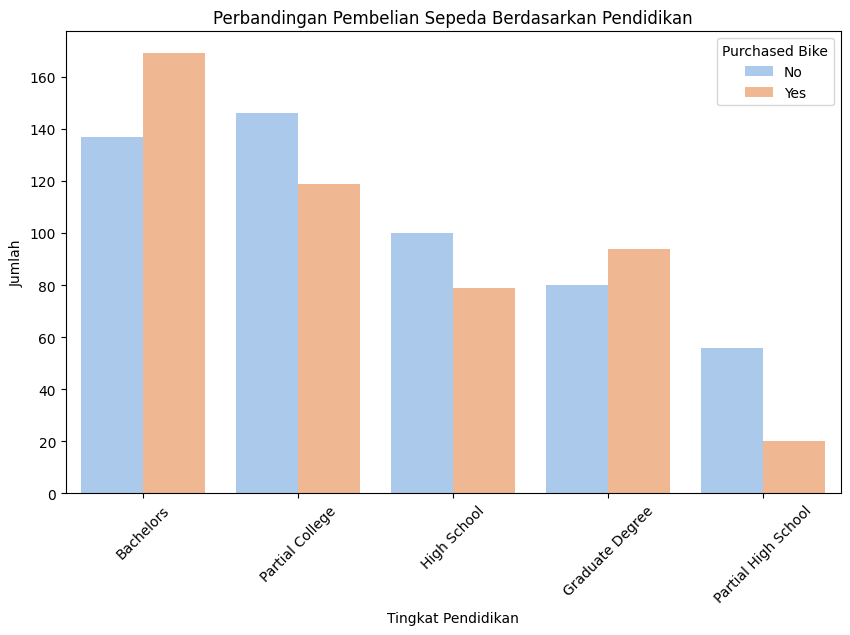

In [175]:
EDUCATION = df['Education'].value_counts().head(5).sort_values(ascending=False)
DFEDUCATION = df[df['Education'].isin(EDUCATION.index)]

plt.figure(figsize=(10, 6))
sns.countplot(x='Education', data=DFEDUCATION, hue='Purchased Bike', palette='pastel', order=EDUCATION.index)
plt.title('Perbandingan Pembelian Sepeda Berdasarkan Pendidikan')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()



**Insight**

Berdasarkan hasil visualisasi bar chart di atas, dapat dilihat bahwa tingkat pendidikan memiliki hubungan yang cukup berpengaruh terhadap keputusan pembelian sepeda. Kelompok dengan tingkat pendidikan Bachelors (S1) menjadi satu-satunya kelompok di mana jumlah responden yang membeli sepeda lebih banyak dibandingkan yang tidak membeli, dengan selisih yang cukup signifikan. Hal ini mengindikasikan bahwa lulusan S1 memiliki kecenderungan yang lebih tinggi untuk memilih sepeda sebagai salah satu pilihan transportasi atau gaya hidup mereka.

Di sisi lain, kelompok Partial College dan High School justru menunjukkan pola sebaliknya, di mana jumlah yang tidak membeli sepeda lebih mendominasi meskipun jumlah respondennya tergolong besar. Yang paling mencolok adalah kelompok Partial High School, yang hampir tidak ada respondennya yang memutuskan untuk membeli sepeda. Sementara itu, kelompok Graduate Degree menunjukkan pola yang cenderung seimbang antara yang membeli dan tidak membeli, sehingga kelompok ini dapat dikatakan berada di titik tengah dalam hal keputusan pembelian sepeda.

**Action**

Dari temuan di atas, strategi pemasaran sepeda sebaiknya diprioritaskan pada segmen dengan tingkat pendidikan Bachelors dan Graduate Degree, dikarenakan kedua kelompok ini memiliki tingkat ketertarikan pembelian yang lebih tinggi dibandingkan kelompok lainnya. Adapun untuk kelompok Partial High School dan High School, diperlukan pendekatan pemasaran yang berbeda, misalnya dengan menawarkan program cicilan, harga yang lebih terjangkau, atau promosi yang lebih menekankan manfaat ekonomis sepeda sebagai alat transportasi harian, mengingat rendahnya tingkat pembelian pada kelompok ini kemungkinan besar berkaitan erat dengan keterbatasan daya beli.

##**Pie Chart**

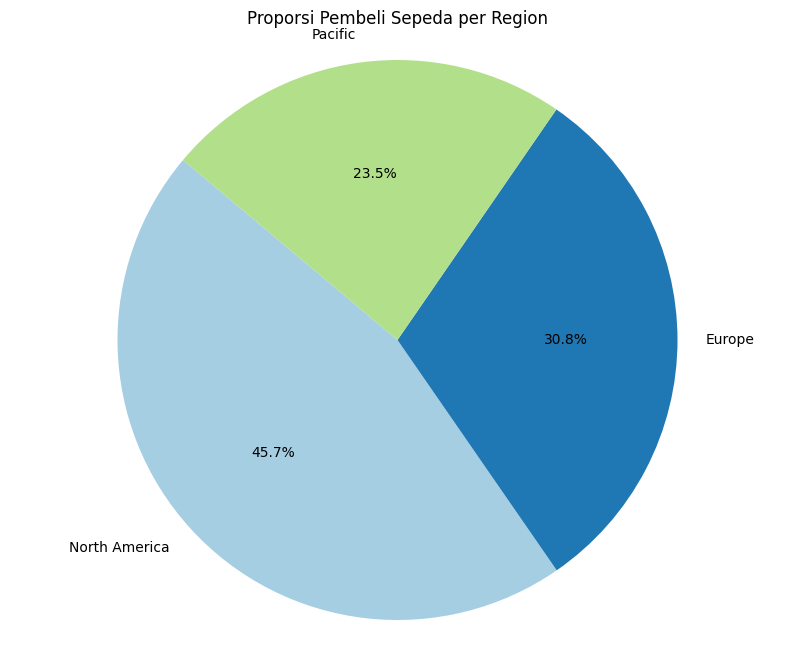

In [176]:
PembeliPerRegion = df[df['Purchased Bike'] == 'Yes'].groupby('Region')['Purchased Bike'].count().sort_values(ascending=False)
Top3Region = PembeliPerRegion.head(3)

plt.figure(figsize=(10, 8))
Top3Region.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi Pembeli Sepeda per Region')
plt.ylabel('')
plt.axis('equal')
plt.show()

**Insight**

Berdasarkan pie chart di atas, dapat diketahui bahwa dari seluruh pembeli sepeda yang tercatat dalam dataset, region North America mendominasi dengan proporsi terbesar yaitu 45.7%, yang berarti hampir separuh dari total pembeli sepeda berasal dari region ini. Posisi kedua ditempati oleh Europe dengan proporsi sebesar 30.8%, sementara Pacific berada di posisi terakhir dengan proporsi 23.5%.

Kesenjangan yang cukup besar antara North America dengan dua region lainnya mengindikasikan bahwa pasar sepeda di North America jauh lebih berkembang dan memiliki basis konsumen yang lebih besar. Hal ini bisa dipengaruhi oleh berbagai faktor seperti budaya bersepeda, infrastruktur yang mendukung, maupun tingkat pendapatan rata-rata masyarakat di region tersebut yang memungkinkan mereka untuk melakukan pembelian sepeda dengan lebih mudah.

**Action**

Berdasarkan analisis di atas maka fokus utama pemasaran dan distribusi sepeda sebaiknya tetap dipertahankan di North America mengingat pasar di region ini sudah terbukti paling luas dan besar. Namun, Europe dan Pacific juga tidak boleh diabaikan dikarenakan proporsi keduanya yang mencapai lebih dari separuh sisanya menunjukkan bahwa potensi pertumbuhan di kedua region tersebut masih sangat besar. Strategi ekspansi pasar yang lebih baik, seperti kampanye pemasaran yang disesuaikan dengan budaya lokal atau kemitraan dengan distributor regional, dapat menjadi langkah yang efektif untuk meningkatkan proporsi penjualan di Europe dan Pacific.

##**Line Chart**

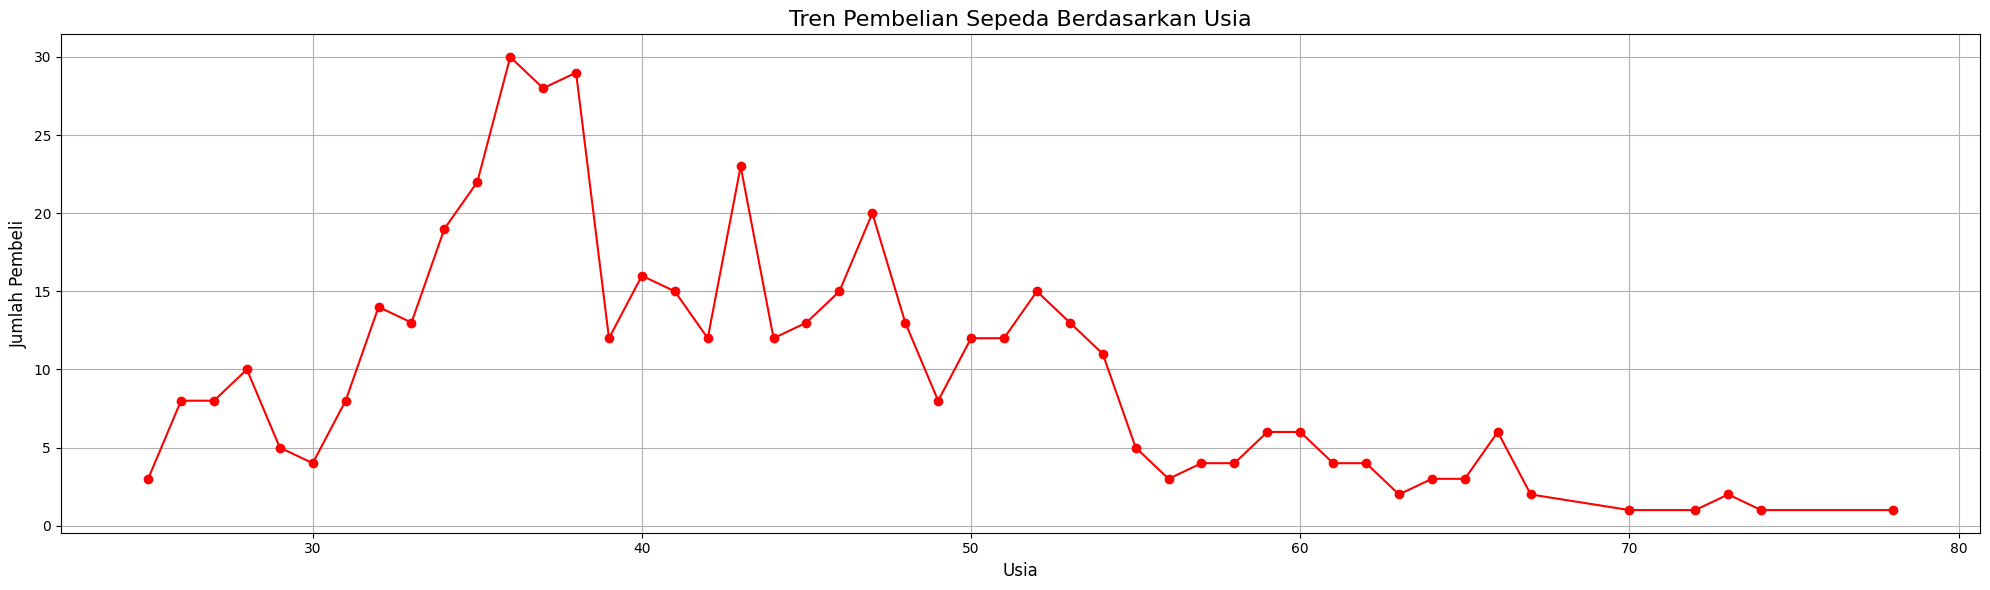

In [177]:
TrenUsia = df[df['Purchased Bike'] == 'Yes'].groupby(df['Age']).size()

plt.figure(figsize=(20, 6))
plt.plot(TrenUsia.index, TrenUsia.values, marker='o', color='red')
plt.title('Tren Pembelian Sepeda Berdasarkan Usia', fontsize=16)
plt.xlabel('Usia', fontsize=12)
plt.ylabel('Jumlah Pembeli', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight**

Berdasarkan line chart di atas, dapat dilihat bahwa tren pembelian sepeda mengalami fluktuasi yang cukup signifikan di berbagai kelompok usia. Puncak pembelian sepeda terjadi pada rentang usia **38–40 tahun**, di mana jumlah pembeli mencapai angka tertinggi sekitar 30 orang. Hal ini mengindikasikan bahwa kelompok usia dewasa pertengahan merupakan segmen yang paling aktif dalam melakukan pembelian sepeda, kemungkinan dikarenakan kelompok usia ini sudah memiliki kestabilan finansial namun masih memiliki gaya hidup yang aktif.

Setelah melewati puncaknya di usia 40 tahun, tren pembelian sepeda menunjukkan  menurun secara konsisten seiring bertambahnya usia. Pada kelompok usia di atas 60 tahun, jumlah pembeli sepeda sudah sangat sedikit dan terus menurun hingga mendekati nol pada usia 75 tahun ke atas. Di sisi lain, kelompok usia muda di bawah 30 tahun juga menunjukkan jumlah pembelian yang relatif rendah, yang kemungkinan berkaitan dengan keterbatasan daya beli pada usia tersebut.

**Action**

Dari temuan ini, strategi pemasaran sepeda sebaiknya difokuskan pada usia 30 hingga 50 tahun sebagai target utama, mengingat kelompok usia ini menunjukkan tingkat pembelian yang paling tinggi dan konsisten. Untuk kelompok usia muda di bawah 30 tahun, pendekatan yang dapat dilakukan mungkin dengan menawarkan program harga yang lebih terjangkau atau skema cicilan/kredit agar dapat meningkatkan daya beli mereka. Sementara itu, untuk kelompok usia di atas 60 tahun, pemasaran dapat diarahkan pada jenis sepeda yang lebih sesuai dengan kebutuhan mereka, seperti sepeda santai atau sepeda listrik yang lebih ringan dan mudah dikendarai, mengingat pada usia mereka akan jarang untuk beraktifitas menggunakan alat transportasi yang dikendarai sendiri.

##**Histogram**

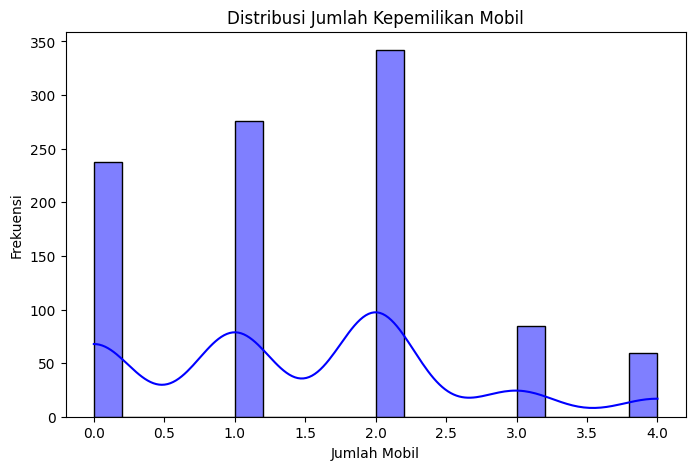

In [178]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Cars'], bins=20, kde=True, color='blue')
plt.title('Distribusi Jumlah Kepemilikan Mobil')
plt.xlabel('Jumlah Mobil')
plt.ylabel('Frekuensi')
plt.show()

**Insight**

Berdasarkan histogram di atas, dapat dilihat bahwa distribusi jumlah kepemilikan mobil dalam dataset ini bersifat diskrit artinya data hanya terpusat pada nilai-nilai bulat (0, 1, 2, 3, dan 4 mobil) tanpa ada nilai di antaranya. Hal ini memanglah wajar karena jumlah kepemilikan mobil memang tidak mungkin bernilai desimal.

Puncak distribusi berada pada kepemilikan 2 mobil, dengan frekuensi tertinggi mendekati 340 responden, menjadikannya kategori yang paling banyak dalam dataset ini. Posisi berikutnya ditempati oleh responden dengan kepemilikan 1 mobil(+-275) dan 0 mobil (+-250), yang menunjukkan bahwa sebagian besar responden memiliki antara 0 hingga 2 mobil. Sementara itu, kepemilikan 3 dan 4 mobil memiliki frekuensi yang jauh lebih rendah, menandakan bahwa kepemilikan mobil dalam jumlah besar merupakan kondisi yang tidak umum di kalangan responden.

**Action**

Temuan ini relevan terhadap keputusan pembelian sepeda karena responden yang memiliki lebih banyak mobil kemungkinan lebih mengandalkan kendaraan lain sebagai alat transportasi utama mereka. Oleh karena itu, strategi pemasaran sepeda dapat lebih diarahkan kepada kelompok dengan kepemilikan 0 hingga 1 mobil, yang dimana ini lebih berpotensi dengan mempertimbangkan sepeda sebagai alternatif transportasi.

##**Box Plot**

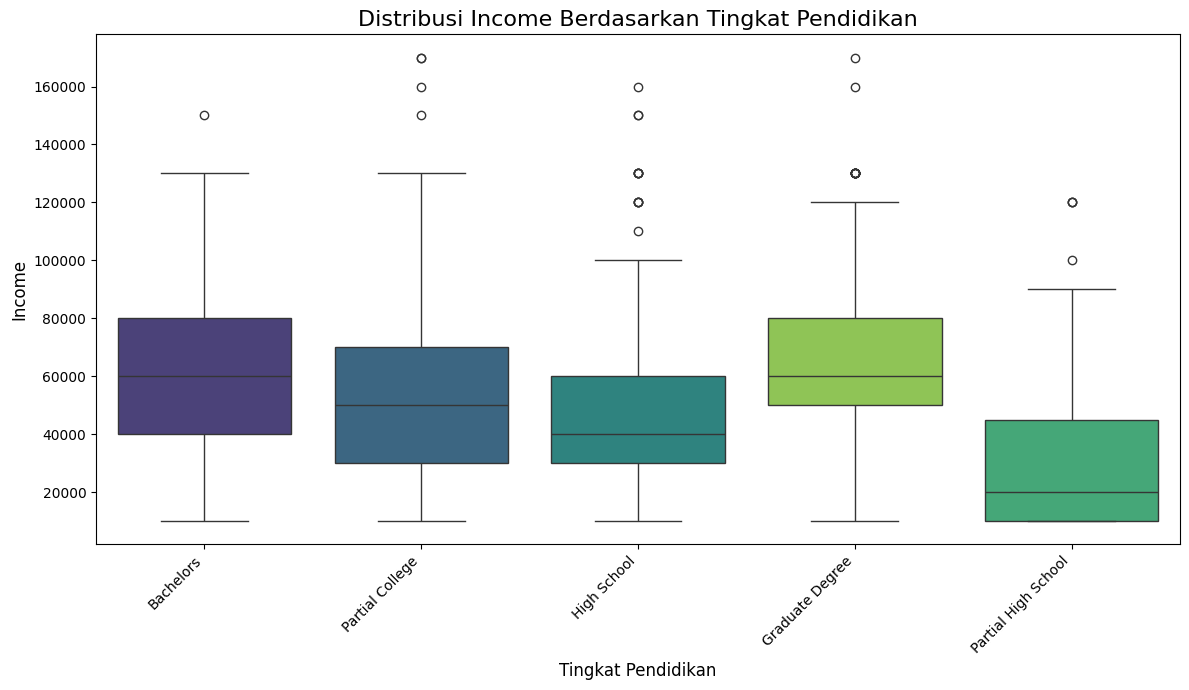

In [179]:
TopEdukasi = df['Education'].value_counts().head(5).index
Filter= df[df['Education'].isin(TopEdukasi)]

plt.figure(figsize=(12, 7))
sns.boxplot(x='Education', y='Income', data=Filter, palette='viridis', order=TopEdukasi, hue='Education', legend=False)
plt.title('Distribusi Income Berdasarkan Tingkat Pendidikan', fontsize=16)
plt.xlabel('Tingkat Pendidikan', fontsize=12)
plt.ylabel('Income', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight**

Berdasarkan boxplot di atas, dapat dilihat bahwa terdapat perbedaan yang cukup jelas dalam distribusi pendapatan (income) antar kelompok tingkat pendidikan. Kelompok Bachelors dan Graduate Degree menunjukkan median income tertinggi, dengan nilai median masing-masing berada di kisaran 60.000 hingga 65.000, serta memiliki rentang distribusi (IQR) yang lebih lebar dibandingkan kelompok lainnya. Hal ini menandakan bahwa lulusan S1 dan pascasarjana cenderung memiliki pendapatan yang lebih tinggi dan lebih bervariasi antar individunya.

Di sisi lain, kelompok Partial High School mencatat median income terendah, yakni sekitar 20.000, dengan distribusi yang sangat sempit di bagian bawah. Ini menunjukkan bahwa responden dengan pendidikan yang tidak tamat SMA umumnya memiliki pendapatan yang rendah dan relatif seragam. Kelompok High School dan Partial College berada di posisi menengah dengan median sekitar 40.000 hingga 50.000. Selain itu, outliers terdeteksi pada hampir semua kelompok pendidikan, yang mengindikasikan bahwa ada sebagian kecil individu di setiap kelompok yang memiliki pendapatan jauh di atas rata-rata kelompoknya.

**Action**

Temuan ini memperkuat kesimpulan sebelumnya bahwa tingkat pendidikan berkorelasi positif dengan tingkat pendapatan seseorang. Dalam konteks pemasaran sepeda, kelompok Bachelors dan Graduate Degree tidak hanya lebih cenderung membeli sepeda, tetapi juga memiliki daya beli yang lebih tinggi, sehingga strategi pemasaran untuk segmen ini dapat diarahkan pada produk sepeda dengan kualitas dan harga yang lebih premium. Sementara itu, untuk kelompok dengan pendidikan dan pendapatan lebih rendah seperti Partial High School, pendekatan yang lebih tepat adalah menawarkan produk sepeda entry-level dengan harga yang lebih terjangkau agar tetap dapat menjangkau segmen tersebut.

##**Scatter Plot**

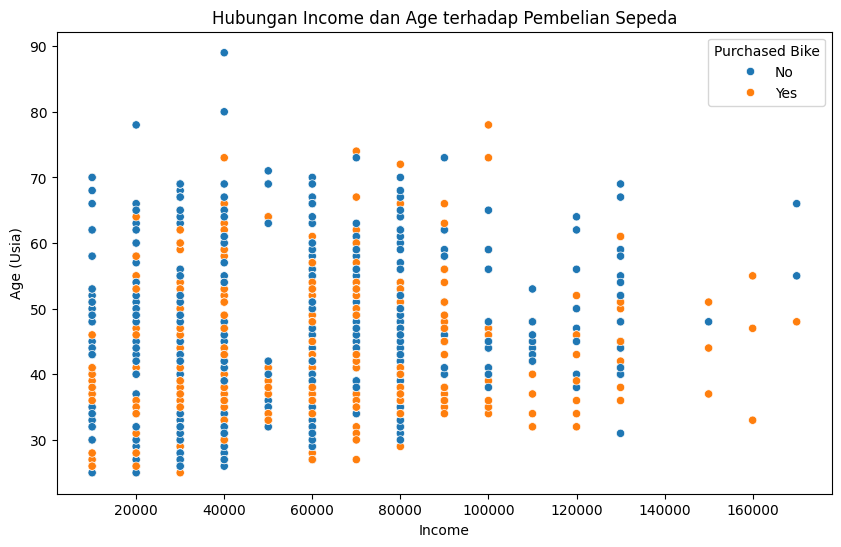

In [180]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Age', hue='Purchased Bike', data=df)
plt.title('Hubungan Income dan Age terhadap Pembelian Sepeda')
plt.xlabel('Income')
plt.ylabel('Age (Usia)')
plt.legend(title='Purchased Bike')
plt.show()

**Insight**

Berdasarkan scatter plot di atas, dapat dilihat persebaran data antara pendapatan (Income) dan usia (Age) terhadap keputusan pembelian sepeda. Secara umum, titik-titik biru (tidak membeli) dan oranye (membeli) tersebar cukup merata di seluruh rentang income dan usia, yang mengindikasikan bahwa tidak ada satu pola dominan yang secara tegas memisahkan pembeli dan non-pembeli hanya berdasarkan kedua variabel ini secara bersamaan.

Tetapi jika diperhatikan lebih tajam, terdapat beberapa pola yang dapat diidentifikasi. Pada kelompok income rendah (40.000 ke bawah), titik biru (tidak membeli) tampak lebih mendominasi dibandingkan titik oranye, yang menunjukkan bahwa responden dengan pendapatan rendah cenderung lebih sedikit yang membeli sepeda. Sebaliknya, pada rentang income menengah hingga tinggi (60.000 hingga 100.000), persebaran antara pembeli dan non-pembeli terlihat lebih seimbang. Dari sisi usia, responden yang membeli sepeda tampak lebih terpusat pada usia 30–55 tahun, sementara pada usia di atas 65 tahun titik biru lebih mendominasi.

**Action**

Temuan ini memperkuat kesimpulan sebelumnya bahwa kombinasi usia produktif dan income menengah ke atas merupakan segmen yang paling potensial untuk dijadikan target pemasaran sepeda. Strategi pemasaran yang menggabungkan kedua dimensi ini, misalnya promosi yang menyasar para profesional berusia 30–55 tahun dengan income di atas 60.000 berpotensi menghasilkan tingkat keberhasilan yang lebih tinggi dibandingkan pendekatan pemasaran yang bersifat umum.

##**HeatMap**

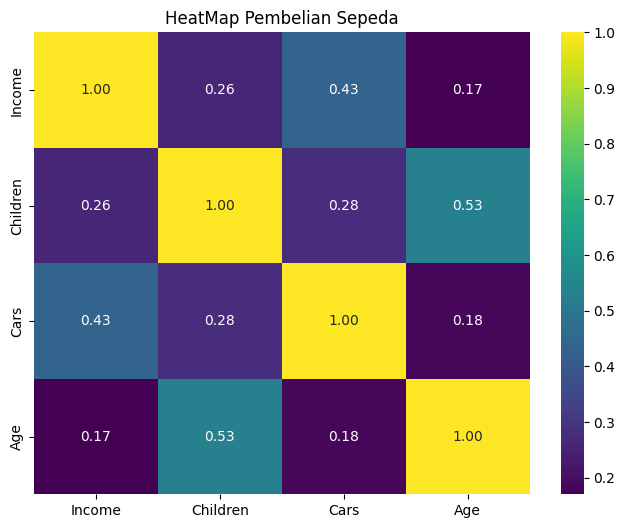

In [181]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Income',	'Children',	'Cars','Age']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('HeatMap Pembelian Sepeda')
plt.show()

**Insight**

Berdasarkan heatmap korelasi di atas, dapat dilihat hubungan antar variabel numerik dalam dataset yaitu Income, Children, Cars, dan Age. Korelasi tertinggi yang tercatat adalah antara Age dan Children sebesar 0.53, yang menunjukkan hubungan positif namu tidak terlalu kuat yang berarti semakin tua usia seseorang, cenderung semakin banyak pula jumlah anak yang dimiliki. Hal ini merupakan pola yang wajar dan sejalan dengan kondisi demografis pada umumnya.

Korelasi tertinggi berikutnya adalah antara Income dan Cars sebesar 0.43, yang mengindikasikan bahwa responden dengan pendapatan lebih tinggi cenderung memiliki lebih banyak mobil. Meskipun hubungan ini tidak terlalu kuat, pola ini tetap relevan karena kepemilikan kendaraan bermotor umumnya berkaitan erat dengan kemampuan finansial seseorang. Sementara itu, variabel Income dan Age hanya memiliki korelasi sebesar 0.17, yang berarti usia tidak terlalu berpengaruh terhadap tingkat pendapatan dalam dataset ini.

Secara keseluruhan, tidak ada pasangan variabel yang memiliki korelasi sangat tinggi (di atas 0.7), sehingga dapat disimpulkan bahwa masing-masing variabel bersifat cukup independen satu sama lain dan tidak terjadi masalah multikolinearitas yang signifikan dalam dataset ini.

**Action**

Temuan korelasi antara Age dan Children serta Income dan Cars dapat dimanfaatkan sebagai dasar dalam membangun segmentasi pelanggan yang lebih tajam. Misalnya, responden berusia lebih tua dengan banyak anak dan pendapatan menengah dapat menjadi segmen tersendiri yang membutuhkan pendekatan pemasaran berbeda, di mana sepeda dapat dipromosikan sebagai solusi transportasi keluarga yang ekonomis.